# Q2.5 Dead Neurons

In [8]:
import sys
from pathlib import Path
import argparse
import numpy as np
import matplotlib.pyplot as plt
import wandb

project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.data_loader import load_dataset
from src.ann.neural_network import NeuralNetwork

ENTITY = 'anandhakrishnanm21-indian-institute-of-technology-madras'


In [6]:
def to_namespace(cfg):
    d = dict(cfg)
    defaults = {
        'hidden_size': [128, 128],
        'activation': 'relu',
        'weight_init': 'xavier',
        'loss': 'cross_entropy',
        'learning_rate': 1e-3,
        'weight_decay': 0.0,
        'optimizer': 'sgd',
        'epochs': 10,
        'batch_size': 64,
    }
    defaults.update(d)
    defaults['num_layers'] = len(defaults['hidden_size'])
    return argparse.Namespace(**defaults)


def evaluate_split(model, X, Y):
    loss, acc = model.evaluate(X, Y)
    return {
        'loss': float(loss),
        'acc': float(acc),
    }


def train_one_run(cfg, project, run_name, dataset_name='mnist', extras_fn=None):
    run = wandb.init(project=project, name=run_name, config=cfg, reinit=True)
    args = to_namespace(wandb.config)

    Xtr, Ytr, Xva, Yva, _, _ = load_dataset(dataset_name)
    model = NeuralNetwork(args)

    best_val_acc = -1.0
    for epoch in range(args.epochs):
        model.train(Xtr, Ytr, epochs=1, batch_size=args.batch_size, X_val=Xva, y_val=Yva, verbose=False)
        tr = evaluate_split(model, Xtr, Ytr)
        va = evaluate_split(model, Xva, Yva)

        payload = {
            'epoch': epoch + 1,
            'train_loss': tr['loss'], 'train_acc': tr['acc'],
            'val_loss': va['loss'], 'val_acc': va['acc'],
        }
        if extras_fn is not None:
            payload.update(extras_fn(model, Xva, Yva))
        wandb.log(payload)

        if va['acc'] > best_val_acc:
            best_val_acc = va['acc']

    wandb.summary['best_val_acc'] = float(best_val_acc)
    wandb.finish()
    return model, Xva


In [ ]:
def dead_neuron_extras(model, X_val, Y_val):
    probe_n = min(1024, X_val.shape[0])
    X_probe = X_val[:probe_n]
    Y_probe = Y_val[:probe_n]

    logits = model.forward(X_probe)
    _ = model.backward(Y_probe, logits)

    out = {}
    for i in range(1, len(model._a_cache)):
        a = model._a_cache[i]
        out[f'dead_ratio_layer_{i}'] = float(np.mean(np.all(np.isclose(a, 0.0), axis=0)))
        out[f'activation_mean_layer_{i}'] = float(np.mean(a))
        out[f'activation_std_layer_{i}'] = float(np.std(a))

    for i, layer in enumerate(model.layers, start=1):
        gw_norm = float(np.linalg.norm(layer.grad_W))
        gb_norm = float(np.linalg.norm(layer.grad_b))
        out[f'grad_norm_W_layer_{i}'] = gw_norm
        out[f'grad_norm_b_layer_{i}'] = gb_norm
        out[f'grad_norm_layer_{i}'] = float(np.sqrt(gw_norm * gw_norm + gb_norm * gb_norm))

    return out


def collect_activation_distributions(model, X, max_probe=2048, max_points=40000, seed=42):
    probe_n = min(max_probe, X.shape[0])
    X_probe = X[:probe_n]

    _ = model.forward(X_probe)
    rng = np.random.default_rng(seed)

    out = {}
    for i in range(1, len(model._a_cache)):
        a = model._a_cache[i].reshape(-1)
        if a.size > max_points:
            idx = rng.choice(a.size, size=max_points, replace=False)
            a = a[idx]
        out[i] = a
    return out


def plot_activation_distributions(distributions_by_activation):
    names = list(distributions_by_activation.keys())
    fig, axes = plt.subplots(1, len(names), figsize=(6 * len(names), 4), sharey=True)
    if len(names) == 1:
        axes = [axes]

    for ax, name in zip(axes, names):
        for layer_idx, values in distributions_by_activation[name].items():
            ax.hist(values, bins=60, density=True, histtype='step', linewidth=1.4, label=f'Layer {layer_idx}')
        ax.set_title(f'{name.upper()} activation distribution')
        ax.set_xlabel('Activation value')
        ax.grid(alpha=0.2, linestyle='--')

    axes[0].set_ylabel('Density')
    axes[-1].legend(title='Hidden layer', fontsize=8)
    plt.tight_layout()
    plt.show()


PROJECT = 'q2_5_dead_neurons'
activation_distributions = {}
for activation in ['relu', 'tanh']:
    cfg = {
        'epochs': 20, 'batch_size': 64, 'learning_rate': 0.05,
        'weight_decay': 0.0, 'optimizer': 'rmsprop', 'activation': activation,
        'hidden_size': [128, 128, 128], 'weight_init': 'xavier', 'loss': 'cross_entropy'
    }
    model, Xva = train_one_run(
        cfg,
        project=PROJECT,
        run_name=f'dead_{activation}_lr{cfg["learning_rate"]}',
        dataset_name='mnist',
        extras_fn=dead_neuron_extras,
    )
    activation_distributions[activation] = collect_activation_distributions(model, Xva)





activation_mean_layer_1,▂▁▂▆▄▃▅▂▂▂▂▃▃▄▆▆▇█▇▅
activation_mean_layer_2,▁▁▁▃▂▂▃▂▂▃▂▃▄█▄▇▆▆▇▆
activation_mean_layer_3,▁▁▁▃▄▃▄▃▄▄▄▃▅█▆▆▅▆▅▅
activation_std_layer_1,▁▁▂▄▄▃▅▃▃▃▃▄▄▆▇▇▇██▆
activation_std_layer_2,▁▁▁▃▂▂▄▃▃▃▃▃▄█▄▇▆▆▇▆
activation_std_layer_3,▁▃▂▅▅▅▆▄▅▅▆▄▆█▅█▅█▇█
dead_ratio_layer_1,▆█▆▃▆▁▃▆▃▃▃▃▃▃▃▃▁▃▃▃
dead_ratio_layer_2,▁▆▃▇█▇▅▂▃▃▁▂▃▄▄▃▆▆▇█
dead_ratio_layer_3,▇▆▇█▆▇▆▅▅▄▄▂▃▁▂▄▅▆▆▇
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
+16,...


activation_mean_layer_1,▁▁▁▁▁▁▁▁▁▁▁████▃▃▃▃▃
activation_mean_layer_2,███████████▁▁▁▂█████
activation_mean_layer_3,▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅█████
activation_std_layer_1,▁▁▁▁▁▁▁▁▁▁▁▆▆▆▆█████
activation_std_layer_2,███████████▁▁▁▂█████
activation_std_layer_3,███████████▅▅▅▅▁▁▁▁▁
dead_ratio_layer_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dead_ratio_layer_2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dead_ratio_layer_3,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
+16,...


NameError: name 'plt' is not defined

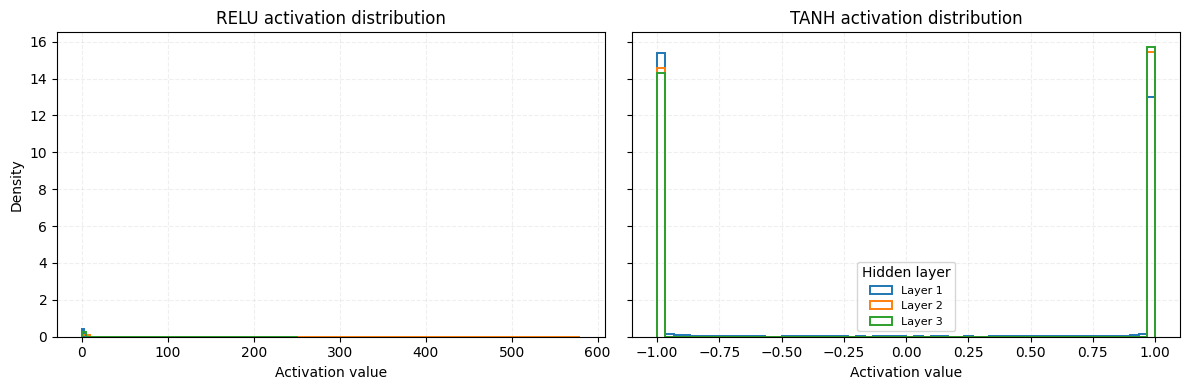

In [9]:
plot_activation_distributions(activation_distributions)
